# Titanic Survival Prediction

# Chapter 1 Data Loading

## 1.1 Import Libraries


In [59]:
# Data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Machine learning
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Font settings (for Chinese labels, if needed)
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# Display plots inline in Notebook
%matplotlib inline

# Set seaborn style
sns.set_style('whitegrid')

## 1.2 Load Data


In [60]:
# Read CSV files
import os
DATA_DIR = '/kaggle/input/competitions/titanic' if os.path.exists('/kaggle/input') else '../data'
SUB_DIR  = '/kaggle/working' if os.path.exists('/kaggle/input') else '../submissions'

train = pd.read_csv(f'{DATA_DIR}/train.csv')
test = pd.read_csv(f'{DATA_DIR}/test.csv')

# Merge into one dataset for unified processing (we'll split again later)
# Tag the source first
train['Source'] = 'train'
test['Source'] = 'test'
test['Survived'] = np.nan  # Test set has no Survived column, fill with NaN

# Combine
full = pd.concat([train, test], axis=0, ignore_index=True)

print(f'Training set shape: {train.shape}')
print(f'Test set shape: {test.shape}')
print(f'Combined shape: {full.shape}')

Training set shape: (891, 13)
Test set shape: (418, 13)
Combined shape: (1309, 13)


## 1.3 Look at the Data

In [61]:
# View the first 5 rows
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Source
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,train
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,train
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,train
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,train
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,train


In [62]:
# View basic data info
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  Source       891 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 90.6+ KB


In [63]:
# Summary statistics for numeric features
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [64]:
# Summary statistics for categorical features
train.describe(include=['O'])

,Name,Sex,Ticket,Cabin,Embarked,Source
count,891,891,891,204,889,891
unique,891,2,681,147,3,1
top,"Dooley, Mr. Patrick",male,347082,G6,S,train
freq,1,577,7,4,644,891


> **What to pay attention to**:
> - Which columns have missing values? → Age, Cabin, Embarked
> - Which are numeric? Which are categorical? → This determines your encoding strategy
> - What's the distribution of the target variable (Survived)? → Is it balanced?


# Chapter 2 Exploratory Data Analysis (EDA)

> **Core idea**: EDA isn't about making pretty charts. It's about **finding patterns and forming hypotheses**. Every chart should help you make a decision.

## 2.1 Target Variable Distribution

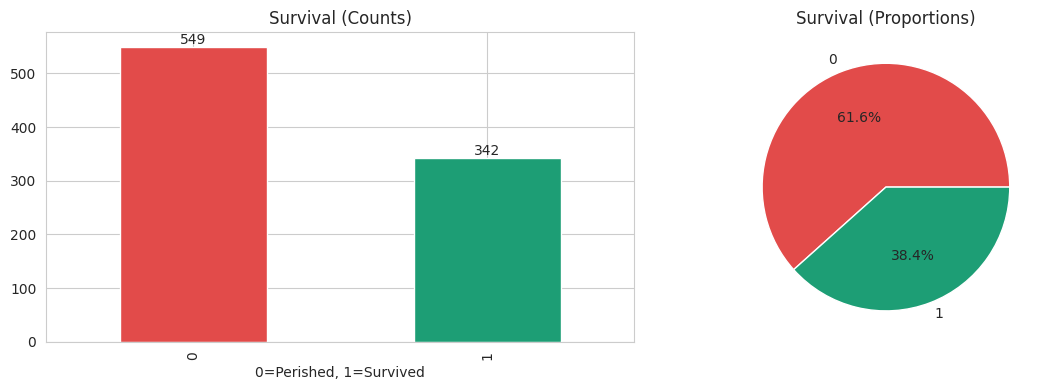

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Counts
train['Survived'].value_counts().plot(kind='bar', ax=axes[0], color=['#E24B4A', '#1D9E75'])
axes[0].set_title('Survival (Counts)')
axes[0].set_xlabel('0=Perished, 1=Survived')
for c in axes[0].containers:
    axes[0].bar_label(c)

# Proportions
train['Survived'].value_counts(normalize=True).plot(kind='pie', ax=axes[1],
    autopct='%1.1f%%', colors=['#E24B4A', '#1D9E75'])
axes[1].set_title('Survival (Proportions)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Finding**: About 61.6% perished and 38.4% survived. Slightly imbalanced, but not severely.

## 2.2 Missing Value Analysis

In [66]:
# Method 1: Direct calculation with pandas
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(missing_df)

          Missing Count  Missing %
Cabin               687      77.10
Age                 177      19.87
Embarked              2       0.22


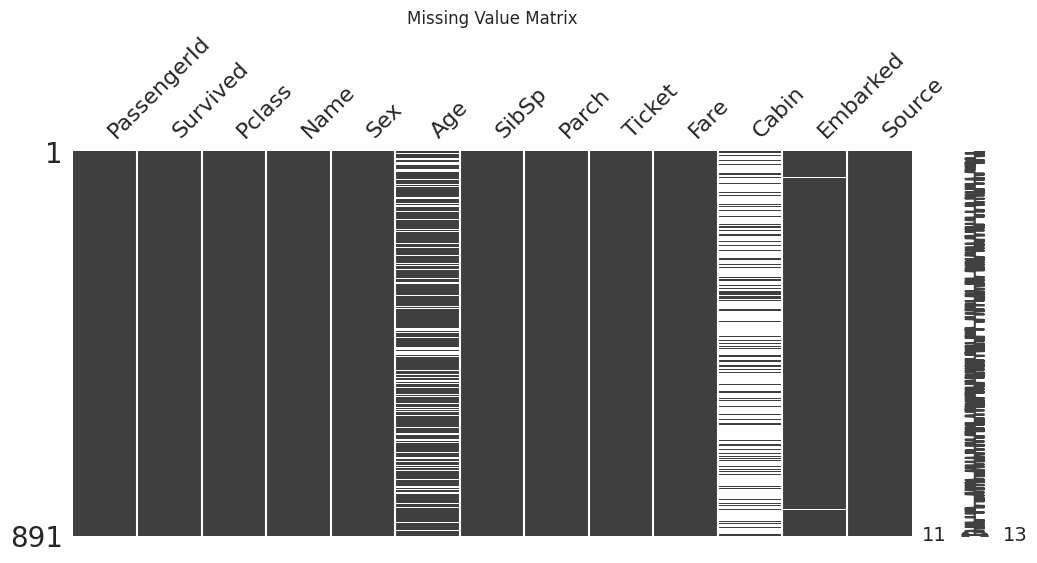

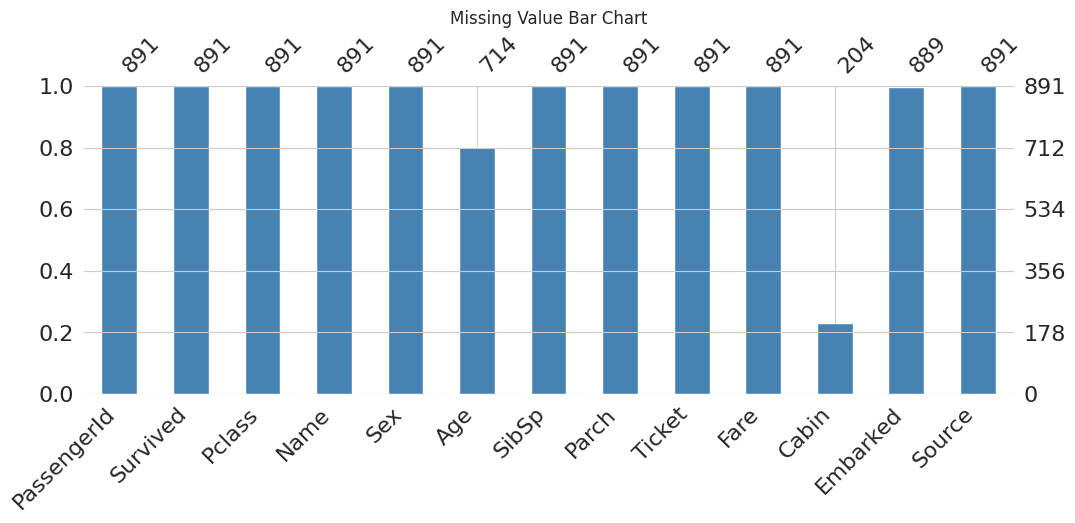

In [67]:
# Method 2: Visualization with missingno (more intuitive)
msno.matrix(train, figsize=(12, 5))
plt.title('Missing Value Matrix')
plt.show()

msno.bar(train, figsize=(12, 4), color='steelblue')
plt.title('Missing Value Bar Chart')
plt.show()

**Findings and decisions**:
| Feature | Missing % | Strategy |
|---------|-----------|----------|
| Cabin | 77.1% | Too much missing. Extract a "has cabin" feature, then consider dropping |
| Age | 19.9% | Can't just drop it. Use smart imputation (group by title/class) |
| Embarked | 0.2% | Only 2 rows. Fill with the mode |

## 2.3 Categorical Features vs. Survival Rate

### Sex

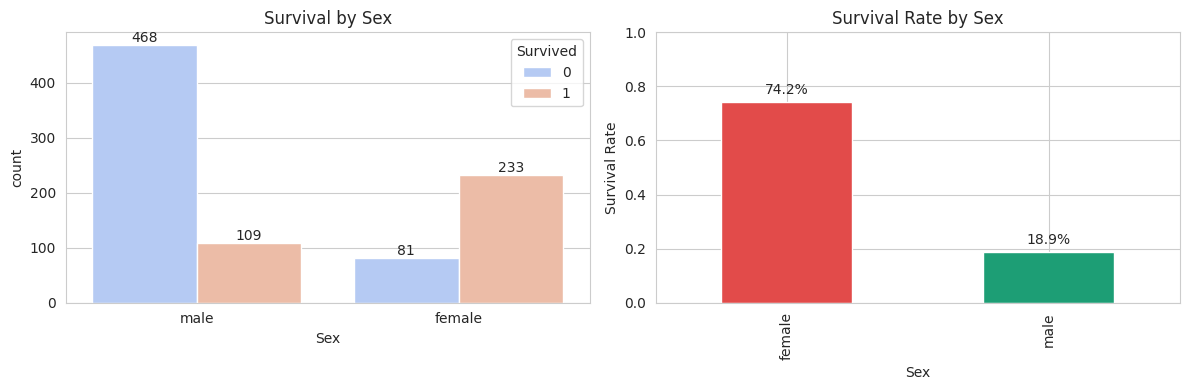

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(x='Sex', hue='Survived', data=train, ax=axes[0], palette='coolwarm')
axes[0].set_title('Survival by Sex')
for c in axes[0].containers:
    axes[0].bar_label(c)

# Survival rate
survival_by_sex = train.groupby('Sex')['Survived'].mean()
survival_by_sex.plot(kind='bar', ax=axes[1], color=['#E24B4A', '#1D9E75'])
axes[1].set_title('Survival Rate by Sex')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)
for i, v in enumerate(survival_by_sex):
    axes[1].text(i, v + 0.03, f'{v:.1%}', ha='center')

plt.tight_layout()
plt.show()

**Key finding**: Female survival rate is about 74%, while male survival rate is only about 19%. 

**Sex is the single strongest predictor.**

### Ticket Class

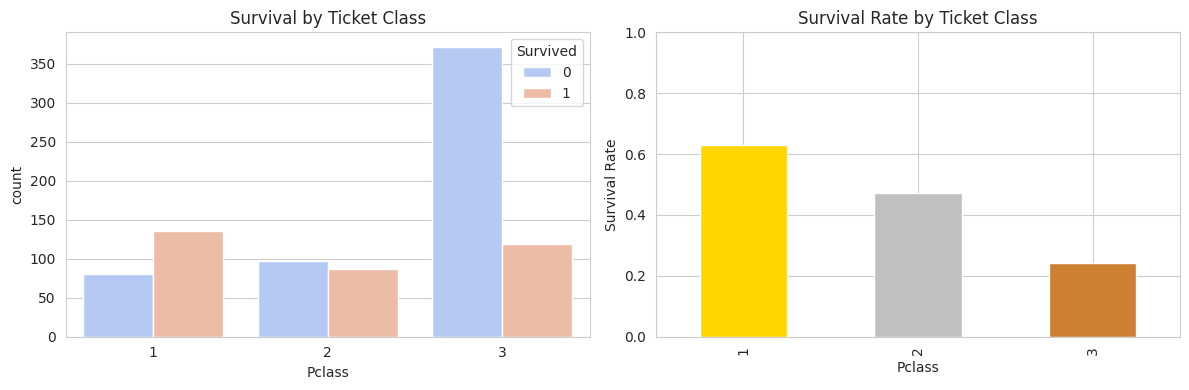

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='Pclass', hue='Survived', data=train, ax=axes[0], palette='coolwarm')
axes[0].set_title('Survival by Ticket Class')

survival_by_pclass = train.groupby('Pclass')['Survived'].mean()
survival_by_pclass.plot(kind='bar', ax=axes[1], color=['#FFD700', '#C0C0C0', '#CD7F32'])
axes[1].set_title('Survival Rate by Ticket Class')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

**Key finding**: 1st class survival rate was 63%, 2nd class 47%, and 3rd class only 24%. 

Social status influenced who survived.

### Sex × Class (Cross Analysis)

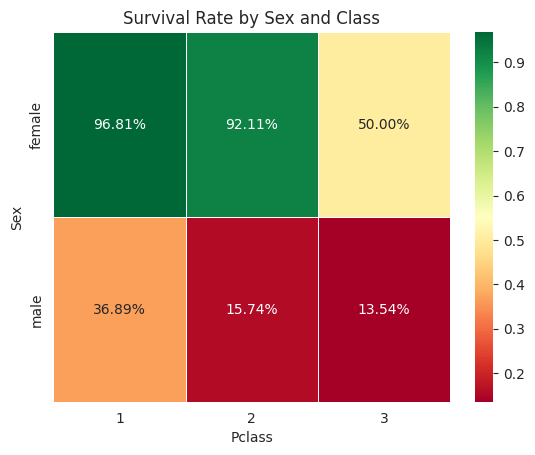

In [70]:
pivot = train.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.2%', cmap='RdYlGn', linewidths=0.5)
plt.title('Survival Rate by Sex and Class')
plt.show()

**Key finding**: 1st class women had a 96% survival rate, while 3rd class men had only 13%. 

The combined effect of both factors is clear.

### Port of Embarkation

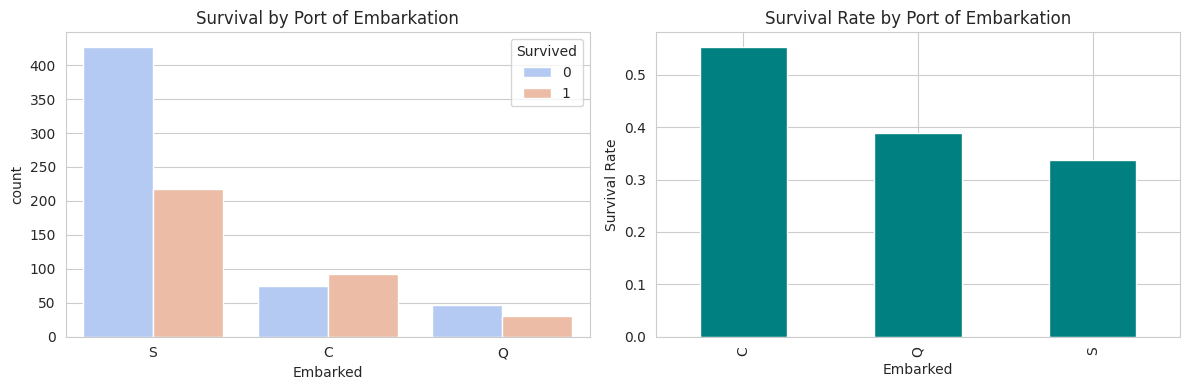

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='Embarked', hue='Survived', data=train, ax=axes[0], palette='coolwarm')
axes[0].set_title('Survival by Port of Embarkation')

train.groupby('Embarked')['Survived'].mean().plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Survival Rate by Port of Embarkation')
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

**Key finding**: Cherbourg (C) had the highest survival rate at 55%, likely because more 1st class passengers boarded there.

## 2.4 Numeric Features vs. Survival Rate

### Age

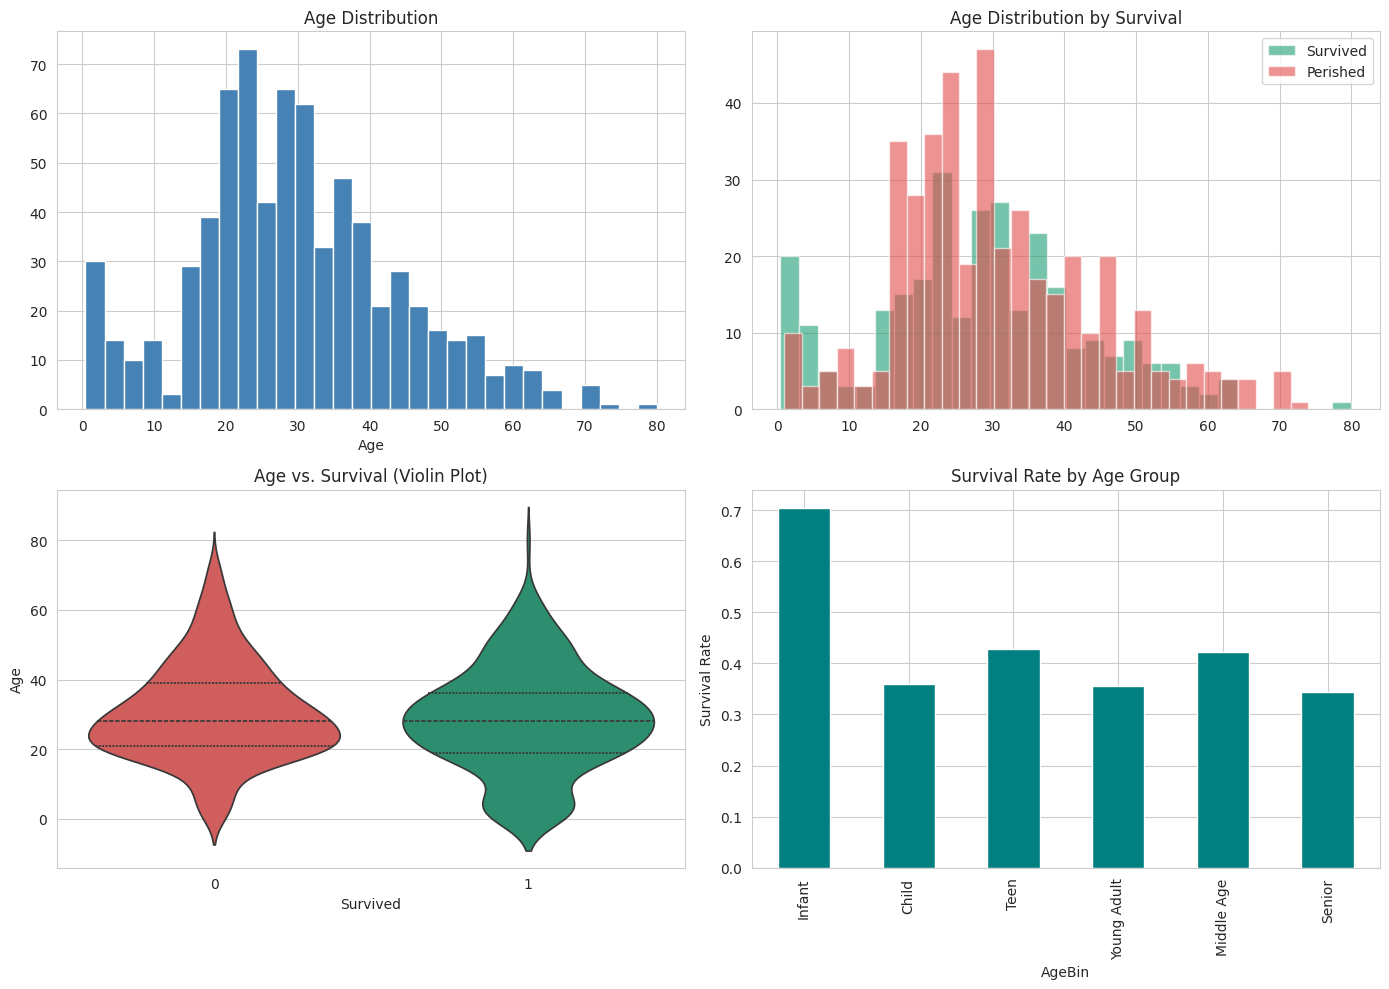

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution
axes[0,0].hist(train['Age'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')

# Age distribution split by survival
train[train['Survived']==1]['Age'].hist(bins=30, alpha=0.6, label='Survived', color='#1D9E75', ax=axes[0,1])
train[train['Survived']==0]['Age'].hist(bins=30, alpha=0.6, label='Perished', color='#E24B4A', ax=axes[0,1])
axes[0,1].set_title('Age Distribution by Survival')
axes[0,1].legend()

# Violin plot
sns.violinplot(x='Survived', y='Age', data=train, hue='Survived',
               palette=['#E24B4A', '#1D9E75'], ax=axes[1,0], legend=False, inner='quartile')
axes[1,0].set_title('Age vs. Survival (Violin Plot)')

# Survival rate by age group
train['AgeBin'] = pd.cut(train['Age'], bins=[0, 5, 12, 18, 30, 50, 80],
                         labels=['Infant', 'Child', 'Teen', 'Young Adult', 'Middle Age', 'Senior'])
train.groupby('AgeBin', observed=False)['Survived'].mean().plot(kind='bar', ax=axes[1,1], color='teal')
axes[1,1].set_title('Survival Rate by Age Group')
axes[1,1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

# Clean up temporary column
train.drop('AgeBin', axis=1, inplace=True)

**Key finding**: Infants (0-5 years old) had a noticeably higher survival rate than other age groups, reflecting the "women and children first" principle.

### Fare

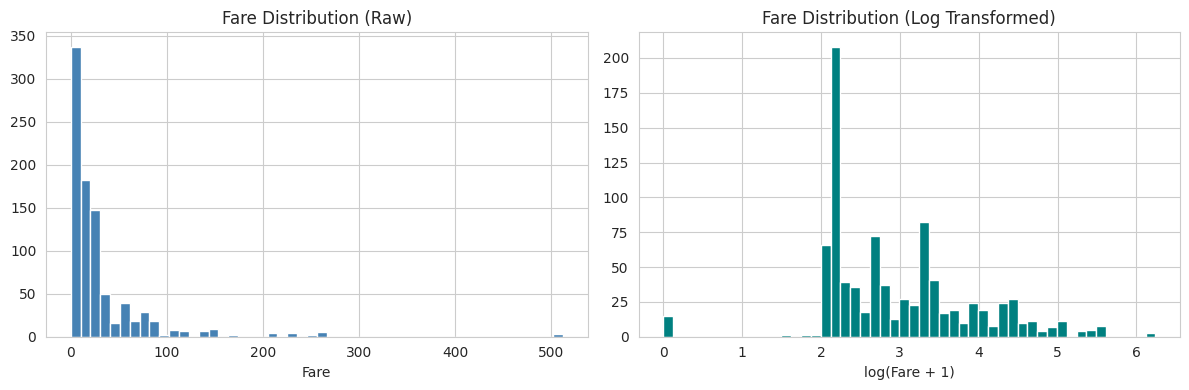

Fare skewness (raw): 4.79
Fare skewness (log transformed): 0.39


In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Fare distribution (note the skew)
axes[0].hist(train['Fare'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Fare Distribution (Raw)')
axes[0].set_xlabel('Fare')

# After log transform
axes[1].hist(np.log1p(train['Fare']), bins=50, color='teal', edgecolor='white')
axes[1].set_title('Fare Distribution (Log Transformed)')
axes[1].set_xlabel('log(Fare + 1)')

plt.tight_layout()
plt.show()

# Skewness of fare
print(f"Fare skewness (raw): {train['Fare'].skew():.2f}")
print(f"Fare skewness (log transformed): {np.log1p(train['Fare']).skew():.2f}")


**Key finding**: Fare is heavily right-skewed (skew≈4.5). After log transformation, it's close to normal (skew≈0.6). Skewed data affects some models, so we'll apply a log transform later.


### Family Size (SibSp + Parch)

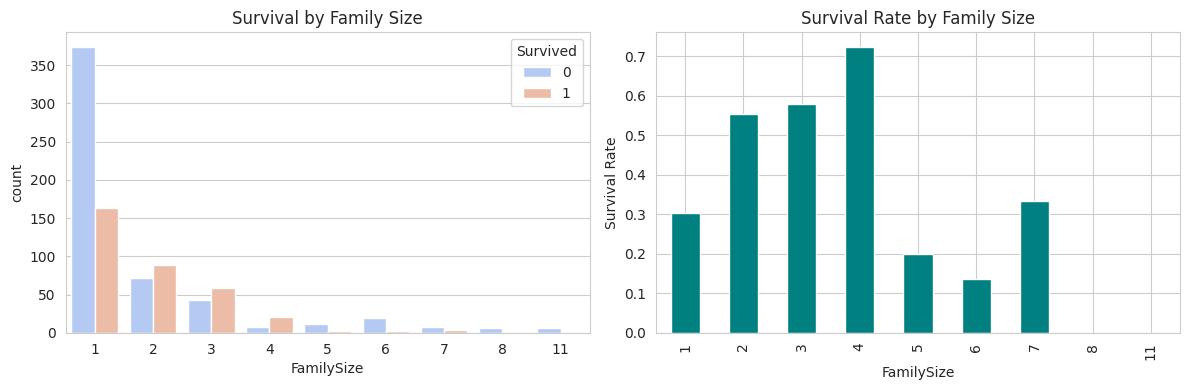

In [74]:
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1  # +1 for the passenger themselves

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='FamilySize', hue='Survived', data=train, ax=axes[0], palette='coolwarm')
axes[0].set_title('Survival by Family Size')

train.groupby('FamilySize')['Survived'].mean().plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Survival Rate by Family Size')
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

# Clean up temporary column
train.drop('FamilySize', axis=1, inplace=True)


**Key finding**: Small families (2-4 people) had the highest survival rate. Solo travelers and large families both had lower rates. This suggests moderate-sized groups helped each other, while being alone or in a very large group was a disadvantage.

## 2.5 Correlation Heatmap

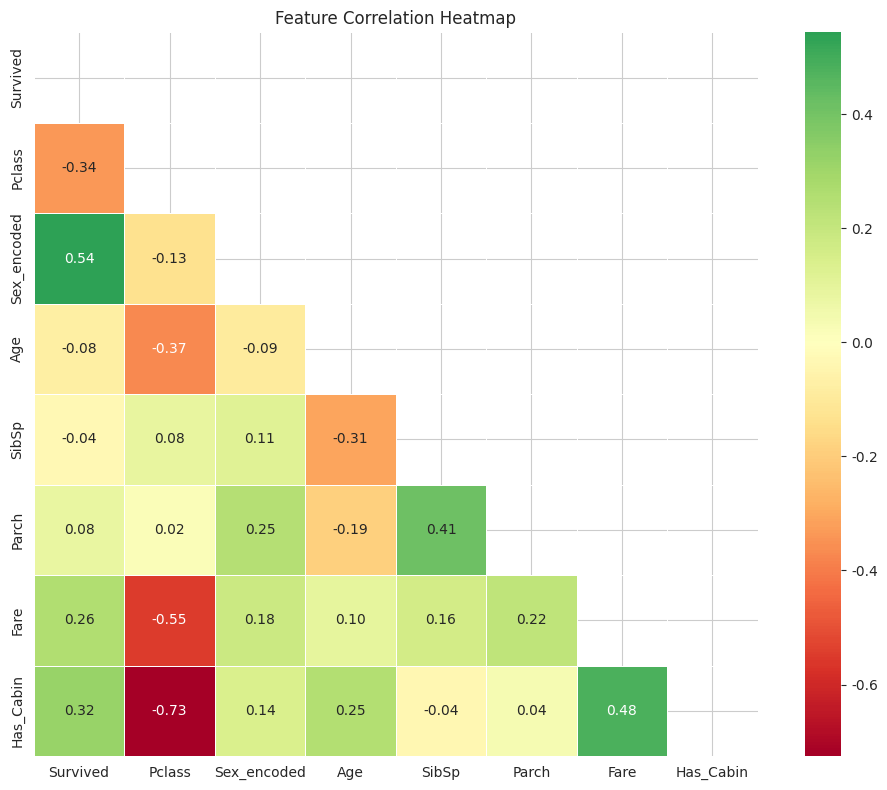

In [75]:
# Encode categorical features first so we can compute correlations
train_corr = train.copy()
train_corr['Sex_encoded'] = (train_corr['Sex'] == 'female').astype(int)
train_corr['Has_Cabin'] = train_corr['Cabin'].notna().astype(int)

corr_cols = ['Survived', 'Pclass', 'Sex_encoded', 'Age', 'SibSp', 'Parch', 'Fare', 'Has_Cabin']
corr_matrix = train_corr[corr_cols].corr()

# Show lower triangle only
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

**Key findings** (sorted by correlation with Survived):

| Feature | Correlation | Interpretation |
|---------|-------------|----------------|
| Sex_encoded | **+0.54** | Strongest positive: female → more likely to survive |
| Pclass | **-0.34** | Negative: higher class number (lower status) → more likely to perish |
| Has_Cabin | **+0.32** | Has cabin number → more likely to survive (mostly 1st class) |
| Fare | **+0.26** | Higher fare → more likely to survive |
| Age | **-0.08** | Weak negative (but masks the nonlinear effect for children) |

> **Note**: Pearson correlation only captures linear relationships. The nonlinear pattern of high child survival gets "averaged out" in a single coefficient. This is why EDA requires more than just numbers. **You have to plot the data**.



## 2.6 EDA Summary: Key Findings

| Finding | Follow-up Action |
|---------|-----------------|
| Female survival rate far exceeds male | Sex is the most important feature. Keep it |
| 1st class > 2nd class > 3rd class | Pclass is a strong predictor |
| Infants had high survival rates | Consider extracting titles from Name (Master/Miss) |
| Small families (2-4) had highest survival | Build a FamilySize feature |
| Fare is heavily right-skewed | Needs log transformation |
| Cabin is 77% missing | Extract "has cabin" or "deck" feature, then drop the raw column |
| Age is 20% missing | Smart imputation grouped by title/class |

---

# Chapter 3 Data Preprocessing

> **Core idea**: The goal of data preprocessing is to make the data "clean" and "model-readable." Clean means handling missing values and outliers. Readable means converting everything to numbers.

## 3.1 Combined Processing Strategy

To avoid inconsistencies between the training and test sets, we merge them and process everything together:

In [76]:
# Reload data (to avoid contamination from EDA modifications)
train = pd.read_csv(f'{DATA_DIR}/train.csv')
test = pd.read_csv(f'{DATA_DIR}/test.csv')

# Tag the source
train['Source'] = 'train'
test['Source'] = 'test'
test['Survived'] = np.nan

full = pd.concat([train, test], axis=0, ignore_index=True)
print(f'Combined data shape: {full.shape}')

Combined data shape: (1309, 13)


## 3.2 Missing Value Handling

### Embarked (only 2 missing)

In [77]:
# Check the 2 missing records
full[full['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Source
61,62,1.0,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,train
829,830,1.0,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,train


Both are 1st class women who paid a fare of 80. Most likely they boarded at Cherbourg (C):

In [78]:
# Fill with the mode (most passengers in 1st class boarded at S, but the difference is minimal)
full['Embarked'] = full['Embarked'].fillna('S')  # Could also use 'C', makes little difference

### Fare (1 missing in test set)

In [79]:
# Check the missing record
full[full['Fare'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Source
1043,1044,NaN,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S,test


In [80]:
# Fill with the median fare for the same class and port
fare_median = full[(full['Pclass'] == 3) & (full['Embarked'] == 'S')]['Fare'].median()
full['Fare'] = full['Fare'].fillna(fare_median)

### Age (roughly 20% missing)

Age has a lot of missing values. A simple mean imputation won't cut it. We'll use **title-grouped imputation**:

In [81]:
# Extract titles first (we'll need this for feature engineering later)
full['Title'] = full['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Check median age by title
full.groupby('Title')['Age'].median().head(10)

Title
Capt        70.0
Col         54.5
Countess    33.0
Don         40.0
Dona        39.0
Dr          49.0
Jonkheer    38.0
Lady        48.0
Major       48.5
Master       4.0
Name: Age, dtype: float64

In [82]:
# Fill missing ages with the title-group median
title_age_median = full.groupby('Title')['Age'].transform('median')
full['Age'] = full['Age'].fillna(title_age_median)

# Verify: are there still missing values?
print(f"Age missing count: {full['Age'].isnull().sum()}")

Age missing count: 0



> **Why is title-based imputation better than mean imputation?** Because title (Mr, Mrs, Miss, Master) correlates strongly with age. "Master" is for young boys (median age ~3.5), while "Mr" is for adult men (median ~30). If you fill everyone with the global mean of 28, you'd turn a 3.5-year-old into a 28-year-old. Completely wrong.

### Cabin (77% missing)

In [83]:
# Extract deck info (first letter), mark missing as 'U' (Unknown)
full['Deck'] = full['Cabin'].fillna('U').apply(lambda x: x[0])
print(full['Deck'].value_counts())

Deck
U    1014
C      94
B      65
D      46
E      41
A      22
F      21
G       5
T       1
Name: count, dtype: int64


Cabin has too much missing data, so we extract just the deck letter and drop the raw Cabin column later.

## 3.3 Data Type Conversion

In [84]:
# Pclass is numeric but actually categorical
full['Pclass'] = full['Pclass'].astype(str)

# Check data types
full.dtypes

PassengerId      int64
Survived       float64
Pclass          object
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
Source          object
Title           object
Deck            object
dtype: object

## 3.4 Encoding Categorical Variables

Machine learning models can only work with numbers, so we need to convert text categories to numeric values:

### Label Encoding (ordinal or binary variables)

In [85]:
# Sex: male→1, female→0 (female has higher survival; we'll one-hot encode later)
full['Sex'] = full['Sex'].map({'male': 1, 'female': 0})

### One-Hot Encoding (nominal categorical variables)

In [86]:
# One-hot encode Embarked and Pclass
full = pd.get_dummies(full, columns=['Embarked', 'Pclass', 'Deck', 'Title'], drop_first=False)

> **What is drop_first?** For binary variables, one-hot encoding creates two perfectly correlated columns (e.g., Embarked_C and Embarked_S. Knowing one tells you the other), causing multicollinearity. But for tree-based models (Random Forest, LightGBM), keeping all columns is fine. For logistic regression, use `drop_first=True`.

## 3.5 Drop Useless Features

In [87]:
# Remove features that don't help with modeling
full = full.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Source'], axis=1)

| Reason for Removal | Feature |
|--------------------|---------|
| Pure ID | PassengerId |
| Info already extracted | Name (extracted Title), Cabin (extracted Deck) |
| Too messy to use | Ticket (inconsistent formats) |
| Helper tag | Source |

## 3.6 Split Back into Training and Test Sets

In [88]:
# Split
X_train = full[full.index < len(train)].drop('Survived', axis=1)
y_train = train['Survived']
X_test = full[full.index >= len(train)].drop('Survived', axis=1)

print(f'Training features: {X_train.shape}, Training labels: {y_train.shape}')
print(f'Test features: {X_test.shape}')

Training features: (891, 38), Training labels: (891,)
Test features: (418, 38)


# Chapter 4 Feature Engineering

> **Core idea**: Feature engineering is the art of squeezing information out of your data. As the saying goes in the industry: **"Data and features set the ceiling for what machine learning can achieve. Models and algorithms just get close to that ceiling."**

## 4.1 What is Feature Engineering?

Feature engineering means **using your human knowledge and creativity to construct more useful signals from raw data**.

Here's an example: the raw data has SibSp (siblings/spouses) and Parch (parents/children). The model might not figure out on its own that these should be added together. By creating `FamilySize = SibSp + Parch + 1`, you're helping the model understand the concept of family size.

## 4.2 Titanic Feature Engineering Checklist

Let's start fresh and systematically engineer features on the combined dataset:

> **Note**: The code below creates a fresh pipeline from scratch. Chapter 3 walked through each step individually; here we combine everything into one clean pipeline and add feature engineering on top. The output of this section is what we'll actually use for modeling.

In [89]:
# Reload clean data
train = pd.read_csv(f'{DATA_DIR}/train.csv')
test = pd.read_csv(f'{DATA_DIR}/test.csv')

train['Source'] = 'train'
test['Source'] = 'test'
test['Survived'] = np.nan

full = pd.concat([train, test], axis=0, ignore_index=True)


### Feature 1: Title — Extract from Name

In [90]:
# Extract title with regex
full['Title'] = full['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Check title distribution
full['Title'].value_counts()

Title
Mr          757
Miss        260
Mrs         197
Master       61
Rev           8
Dr            8
Col           4
Major         2
Mlle          2
Ms            2
Mme           1
Don           1
Sir           1
Lady          1
Capt          1
Countess      1
Jonkheer      1
Dona          1
Name: count, dtype: int64

Many titles appear only a few times and need to be consolidated:

In [91]:
# Consolidate rare titles
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
               'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
full['Title'] = full['Title'].replace(rare_titles, 'Rare')

# Standardize French titles
full['Title'] = full['Title'].replace(['Mlle', 'Ms'], 'Miss')
full['Title'] = full['Title'].replace('Mme', 'Mrs')

# Verify
full['Title'].value_counts()

Title
Mr        757
Miss      264
Mrs       198
Master     61
Rare       29
Name: count, dtype: int64

### Feature 2: FamilySize

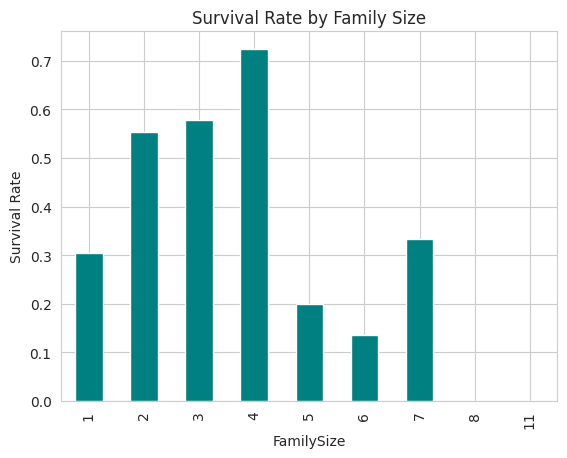

In [92]:
full['FamilySize'] = full['SibSp'] + full['Parch'] + 1

# Visualize family size vs. survival rate
train_temp = full[full['Source'] == 'train'].copy()
train_temp.groupby('FamilySize')['Survived'].mean().plot(kind='bar', color='teal')
plt.title('Survival Rate by Family Size')
plt.ylabel('Survival Rate')
plt.show()

### Feature 3: IsAlone

In [93]:
full['IsAlone'] = (full['FamilySize'] == 1).astype(int)

# Survival rate: alone vs. not alone
train_temp = full[full['Source'] == 'train'].copy()
print(f"Alone survival rate: {train_temp[train_temp['IsAlone']==1]['Survived'].mean():.2%}")
print(f"Not alone survival rate: {train_temp[train_temp['IsAlone']==0]['Survived'].mean():.2%}")

Alone survival rate: 30.35%
Not alone survival rate: 50.56%


### Feature 4: Deck — Extract from Cabin

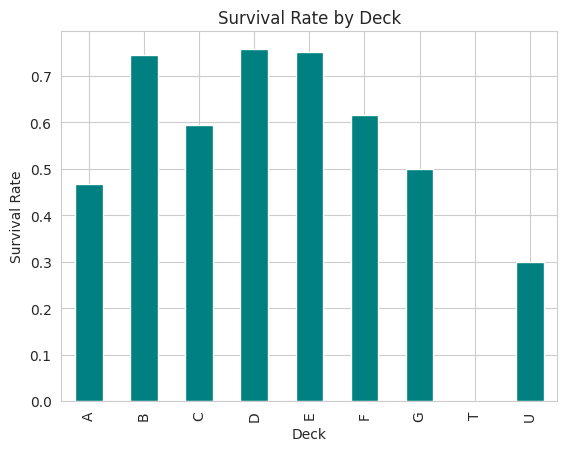

In [94]:
full['Deck'] = full['Cabin'].fillna('U').apply(lambda x: x[0])

# Check deck vs. survival rate
train_temp = full[full['Source'] == 'train'].copy()
train_temp.groupby('Deck')['Survived'].mean().plot(kind='bar', color='teal')
plt.title('Survival Rate by Deck')
plt.ylabel('Survival Rate')
plt.show()

### Feature 5: FarePerPerson

In [95]:
full['FarePerPerson'] = full['Fare'] / full['FamilySize']

### Feature 6: AgeGroup

In [96]:
# First, fill missing Age values (grouped by title median)
full['Age'] = full.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))

# Age groups
full['AgeGroup'] = pd.cut(full['Age'], bins=[0, 5, 12, 18, 35, 60, 100],
                          labels=[0, 1, 2, 3, 4, 5])  # Numeric labels for modeling
full['AgeGroup'] = full['AgeGroup'].astype(int)

### Feature 7: Has_Cabin

In [97]:
full['Has_Cabin'] = full['Cabin'].notna().astype(int)

### Feature 8: Log Transform of Fare

In [98]:
full['Fare_log'] = np.log1p(full['Fare'])

> **Why log transform?** Fare is heavily right-skewed (skew≈4.5). Log transform brings it close to a normal distribution. Linear models like logistic regression are sensitive to skew; tree models aren't affected either way.

## 4.3 Complete Preprocessing and Encoding

In [99]:
# This is the final preprocessing cell — its output feeds directly into Chapter 5 and 6
# Fill remaining missing values
full['Embarked'] = full['Embarked'].fillna('S')
full['Fare'] = full.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))
full['Fare_log'] = np.log1p(full['Fare'])
full['FarePerPerson'] = full['Fare'] / full['FamilySize']

# Encode sex
full['Sex'] = full['Sex'].map({'male': 1, 'female': 0})

# Drop columns no longer needed
full = full.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Source'], axis=1)

# One-hot encoding
full['Pclass'] = full['Pclass'].astype(str)
full = pd.get_dummies(full, columns=['Embarked', 'Pclass', 'Title', 'Deck'], drop_first=False)

# Confirm no missing values remain
print(f"Remaining missing values: {full.isnull().sum().sum()}")

# Split into train/test
X = full[full.index < len(train)].drop('Survived', axis=1)
y = train['Survived']
X_test = full[full.index >= len(train)].drop('Survived', axis=1)

print(f'Training set: {X.shape}, Test set: {X_test.shape}')

Remaining missing values: 418
Training set: (891, 31), Test set: (418, 31)


## 4.4 Principles of Feature Engineering

| Principle | Description |
|-----------|-------------|
| **Domain knowledge first** | "Women and children first" → extract titles, age groups |
| **Combine to create information** | SibSp + Parch → FamilySize → IsAlone |
| **Compress redundant info** | Cabin is 77% missing → keep only "has cabin" and "deck" |
| **Transform away skew** | Fare → Fare_log |
| **Bold hypothesis, careful verification** | After adding each feature, run CV and check if the score improves |

---

# Chapter 5 Model Building and Evaluation

> **Core idea**: Get it working first, then optimize. Start by building a working end-to-end pipeline. Don't try to max out your score right away.

## 5.1 Baseline Model

The purpose of a baseline: **if you can't beat "guess everyone perished," your model is useless.**

In [100]:
# Simplest baseline: everyone perishes
baseline_acc = 1 - y.mean()  # Perish rate
print(f"Baseline accuracy (guess all perished): {baseline_acc:.4f}")

Baseline accuracy (guess all perished): 0.6162


Output: `Baseline accuracy: 0.6162` → Your model must beat 61.6% to be useful.

## 5.2 Multi-Model Comparison

In [101]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
import lightgbm as lgb

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=200, random_state=42),
    'SVM (RBF)': SVC(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'LightGBM': lgb.LGBMClassifier(n_estimators=200, random_state=42, verbose=-1),
}

# 5-fold stratified cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate each model
results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    results[name] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'scores': scores
    }
    print(f"{name:25s} | Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression       | Accuracy: 0.8339 ± 0.0178
Decision Tree             | Accuracy: 0.7733 ± 0.0257
Random Forest             | Accuracy: 0.8092 ± 0.0289
Gradient Boosting         | Accuracy: 0.8339 ± 0.0217
Extra Trees               | Accuracy: 0.8002 ± 0.0229
SVM (RBF)                 | Accuracy: 0.6756 ± 0.0071
KNN                       | Accuracy: 0.7408 ± 0.0077
Naive Bayes               | Accuracy: 0.7845 ± 0.0194
LightGBM                  | Accuracy: 0.8215 ± 0.0188


Extra Trees               | Accuracy: 0.8002 ± 0.0229
SVM (RBF)                 | Accuracy: 0.6756 ± 0.0071


KNN                       | Accuracy: 0.7408 ± 0.0077
Naive Bayes               | Accuracy: 0.7845 ± 0.0194


LightGBM                  | Accuracy: 0.8215 ± 0.0188


Expected output (approximate range):
```
Logistic Regression       | Accuracy: 0.82xx ± 0.01xx
Decision Tree             | Accuracy: 0.78xx ± 0.02xx
Random Forest             | Accuracy: 0.82xx ± 0.02xx
Gradient Boosting         | Accuracy: 0.83xx ± 0.02xx
Extra Trees               | Accuracy: 0.80xx ± 0.02xx
SVM (RBF)                 | Accuracy: 0.66xx ± 0.03xx
KNN                       | Accuracy: 0.73xx ± 0.02xx
Naive Bayes               | Accuracy: 0.77xx ± 0.02xx
LightGBM                  | Accuracy: 0.83xx ± 0.02xx

## 5.3 Visualize the Comparison

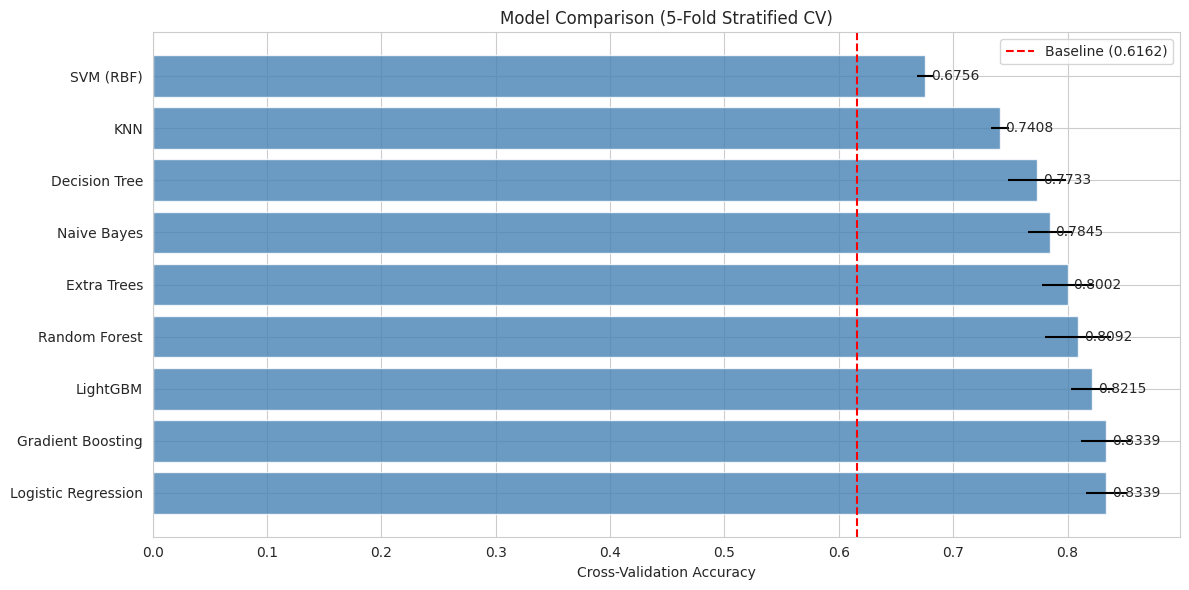

In [102]:
# Sort and plot
sorted_results = sorted(results.items(), key=lambda x: x[1]['mean'], reverse=True)
names = [r[0] for r in sorted_results]
means = [r[1]['mean'] for r in sorted_results]
stds = [r[1]['std'] for r in sorted_results]

plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(names)), means, xerr=stds, color='steelblue', alpha=0.8)
plt.yticks(range(len(names)), names)
plt.xlabel('Cross-Validation Accuracy')
plt.title('Model Comparison (5-Fold Stratified CV)')
plt.axvline(x=baseline_acc, color='red', linestyle='--', label=f'Baseline ({baseline_acc:.4f})')
plt.legend()

# Annotate values
for i, (m, s) in enumerate(zip(means, stds)):
    plt.text(m + 0.005, i, f'{m:.4f}', va='center')

plt.tight_layout()
plt.show()

## 5.4 Why Use Cross-Validation?

| Method | Problem |
|--------|---------|
| Only look at training accuracy | Overfitting! The model may have "memorized" the answers |
| Single train/test split | Results depend on the random seed. Unstable |
| **K-fold cross-validation** | Every data point gets used as validation. Results are reliable |

**The 5-fold CV process:**
```
Round 1: [VALID][ Train ][ Train ][ Train ][ Train ] → Score 1
Round 2: [ Train ][VALID][ Train ][ Train ][ Train ] → Score 2
Round 3: [ Train ][ Train ][VALID][ Train ][ Train ] → Score 3
Round 4: [ Train ][ Train ][ Train ][VALID][ Train ] → Score 4
Round 5: [ Train ][ Train ][ Train ][ Train ][VALID] → Score 5
Final score = Mean ± Std

> **Why StratifiedKFold?** Because the survival rate is about 38%. If you split randomly, some folds might be all perishers. StratifiedKFold ensures each fold has the same survival/perish ratio as the full dataset.

## 5.5 Pick the Best Single Model

Based on cross-validation results, pick the top 2-3 models for further tuning. Usually **LightGBM + Random Forest + Logistic Regression** is a solid combination.

---

# Chapter 6 Hyperparameter Tuning and Model Ensembling

## 6.1 Hyperparameter Tuning

### What Are Hyperparameters?

Hyperparameters are settings you choose **before training** (like number of trees, max depth), as opposed to parameters the model learns during training (like weights).

| Concept | Who Decides | Example |
|---------|-------------|---------|
| Parameters | Learned from data by the model | Linear regression coefficients |
| Hyperparameters | Set manually by you | Random Forest tree count, max depth |

### Method 1: GridSearchCV (Exhaustive Search)

In [103]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=skf, scoring='accuracy',
                           n_jobs=-1, verbose=1)
grid_search.fit(X, y)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 500}
Best CV score: 0.8462


### Method 2: Optuna (Smarter Search)

In [104]:
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
    }
    
    model = lgb.LGBMClassifier(**params, random_state=42, verbose=-1)
    scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Best score: {study.best_value:.4f}")
print(f"Best parameters: {study.best_params}")

[I 2026-07-21 05:09:03,617] A new study created in memory with name: no-name-945576d8-b2c3-4ac2-b67b-5aa27e1f969c
[I 2026-07-21 05:09:05,374] Trial 0 finished with value: 0.84509446990145 and parameters: {'n_estimators': 990, 'max_depth': 8, 'learning_rate': 0.011947750540622207, 'num_leaves': 83, 'min_child_samples': 43, 'subsample': 0.7144936507670101, 'colsample_bytree': 0.839885327287702, 'reg_alpha': 0.8904585648875418, 'reg_lambda': 1.063867907734074}. Best is trial 0 with value: 0.84509446990145.
[I 2026-07-21 05:09:05,759] Trial 1 finished with value: 0.8293955181721173 and parameters: {'n_estimators': 899, 'max_depth': 6, 'learning_rate': 0.08263422766029452, 'num_leaves': 89, 'min_child_samples': 13, 'subsample': 0.7754094180530162, 'colsample_bytree': 0.7351978527552552, 'reg_alpha': 6.507760980370593, 'reg_lambda': 8.892297324193946}. Best is trial 0 with value: 0.84509446990145.
[I 2026-07-21 05:09:06,063] Trial 2 finished with value: 0.8327663046889713 and parameters: {'n

Best score: 0.8496
Best parameters: {'n_estimators': 732, 'max_depth': 14, 'learning_rate': 0.12364360918407269, 'num_leaves': 55, 'min_child_samples': 23, 'subsample': 0.7191400372767198, 'colsample_bytree': 0.8476092340154338, 'reg_alpha': 1.7004807872697598, 'reg_lambda': 2.613934375807118}


[I 2026-07-21 10:07:15,610] Trial 5 finished with value: 0.8316427091833531 and parameters: {'n_estimators': 740, 'max_depth': 5, 'learning_rate': 0.04749470688206827, 'num_leaves': 21, 'min_child_samples': 21, 'subsample': 0.8380075863146155, 'colsample_bytree': 0.9903908434301192, 'reg_alpha': 5.690480204381312, 'reg_lambda': 8.878974447928787}. Best is trial 3 with value: 0.8462306195467955.


[I 2026-07-21 10:07:18,902] Trial 6 finished with value: 0.8226853304877283 and parameters: {'n_estimators': 741, 'max_depth': 15, 'learning_rate': 0.07202350125226062, 'num_leaves': 88, 'min_child_samples': 38, 'subsample': 0.6860885993817986, 'colsample_bytree': 0.7241223136911541, 'reg_alpha': 8.159055019407015, 'reg_lambda': 7.152408976556987}. Best is trial 3 with value: 0.8462306195467955.


[I 2026-07-21 10:07:23,375] Trial 7 finished with value: 0.8372418555018518 and parameters: {'n_estimators': 519, 'max_depth': 4, 'learning_rate': 0.09228321433850786, 'num_leaves': 95, 'min_child_samples': 37, 'subsample': 0.7408993570838535, 'colsample_bytree': 0.8179260113554889, 'reg_alpha': 1.7459560723074785, 'reg_lambda': 9.694359519894988}. Best is trial 3 with value: 0.8462306195467955.


...

[I 2026-07-21 10:12:17,067] Trial 46 finished with value: 0.8484589793484402 and parameters: {'n_estimators': 551, 'max_depth': 14, 'learning_rate': 0.02972096345583862, 'num_leaves': 39, 'min_child_samples': 26, 'subsample': 0.8815236383147811, 'colsample_bytree': 0.7981510843563645, 'reg_alpha': 0.7637408160303167, 'reg_lambda': 1.1934273437317744}. Best is trial 25 with value: 0.849588851923922.


[I 2026-07-21 10:12:31,395] Trial 47 finished with value: 0.8405938108091142 and parameters: {'n_estimators': 687, 'max_depth': 6, 'learning_rate': 0.06342854196651403, 'num_leaves': 34, 'min_child_samples': 22, 'subsample': 0.9065065161377387, 'colsample_bytree': 0.8363024952148316, 'reg_alpha': 0.8283467177454132, 'reg_lambda': 2.8028284613228336}. Best is trial 25 with value: 0.849588851923922.


[I 2026-07-21 10:12:44,225] Trial 48 finished with value: 0.8383403427280147 and parameters: {'n_estimators': 614, 'max_depth': 8, 'learning_rate': 0.07240079475403502, 'num_leaves': 39, 'min_child_samples': 36, 'subsample': 0.877241039558273, 'colsample_bytree': 0.8023080616924063, 'reg_alpha': 0.3712292209623266, 'reg_lambda': 2.1385531032633702}. Best is trial 25 with value: 0.849588851923922.


[I 2026-07-21 10:12:52,753] Trial 49 finished with value: 0.8462243424769318 and parameters: {'n_estimators': 777, 'max_depth': 4, 'learning_rate': 0.05001474037296302, 'num_leaves': 48, 'min_child_samples': 30, 'subsample': 0.964984501642285, 'colsample_bytree': 0.8881740495679314, 'reg_alpha': 0.8309669130259241, 'reg_lambda': 5.922410988443715}. Best is trial 25 with value: 0.849588851923922.


Best score: 0.8496
Best parameters: {'n_estimators': 725, 'max_depth': 8, 'learning_rate': 0.04547602442178069, 'num_leaves': 59, 'min_child_samples': 26, 'subsample': 0.6506889715827499, 'colsample_bytree': 0.8464171099043664, 'reg_alpha': 1.9647777961860786, 'reg_lambda': 2.315962397969293}


> **GridSearch vs Optuna**: GridSearch exhaustively tries every combination. Slow when the grid is large. Optuna uses Bayesian optimization to search smartly, usually finding good parameters faster.

## 6.2 Model Ensembling

### Why Does Ensembling Work?

Different models learn different things:
- Logistic Regression picks up **linear relationships** (e.g., "female → more likely to survive")
- Random Forest captures **nonlinear interactions** (e.g., "3rd class male but with a small family")
- LightGBM may learn **subtle gradient patterns**

Combining their predictions usually outperforms any single model.

### Ensemble Method 1: Hard Voting

In [105]:
from sklearn.ensemble import VotingClassifier

# Pick the top 3 models
voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=200, random_state=42)),
        ('lgbm', lgb.LGBMClassifier(n_estimators=200, random_state=42, verbose=-1)),
    ],
    voting='hard'  # hard = majority vote, soft = probability average
)

scores = cross_val_score(voting_clf, X, y, cv=skf, scoring='accuracy')
print(f"Voting ensemble accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

Voting ensemble accuracy: 0.8260 ± 0.0140


### Ensemble Method 2: Soft Voting (Probability-Weighted Average)

In [106]:
# Soft voting requires models that output probabilities
voting_clf_soft = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=200, random_state=42)),
        ('lgbm', lgb.LGBMClassifier(n_estimators=200, random_state=42, verbose=-1)),
        ('gb', GradientBoostingClassifier(n_estimators=200, random_state=42)),
    ],
    voting='soft'  # Probability-based weighted average
)

scores = cross_val_score(voting_clf_soft, X, y, cv=skf, scoring='accuracy')
print(f"Soft voting ensemble accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

Soft voting ensemble accuracy: 0.8406 ± 0.0138


### Ensemble Method 3: Stacking

In [107]:
from sklearn.ensemble import StackingClassifier

# Define base models
base_models = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42)),
    ('lgbm', lgb.LGBMClassifier(n_estimators=200, random_state=42, verbose=-1)),
    ('gb', GradientBoostingClassifier(n_estimators=200, random_state=42)),
]

# Meta-model (second layer. Uses base model predictions as features)
meta_model = LogisticRegression(max_iter=1000, random_state=42)

stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    passthrough=False  # Whether to pass original features to the meta-model too
)

scores = cross_val_score(stacking_clf, X, y, cv=skf, scoring='accuracy')
print(f"Stacking ensemble accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

Stacking ensemble accuracy: 0.8417 ± 0.0132


## 6.3 Manual Weighted Ensemble (Advanced)

In [108]:
# Train each model separately and get prediction probabilities
from sklearn.model_selection import cross_val_predict

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Get OOF (Out-of-Fold) predictions
lgbm_model = lgb.LGBMClassifier(**study.best_params, random_state=42, verbose=-1)
rf_model = RandomForestClassifier(**grid_search.best_params_)
gb_model = GradientBoostingClassifier(n_estimators=200, random_state=42)
lr_model = LogisticRegression(max_iter=1000, random_state=42)

lgbm_oof = cross_val_predict(lgbm_model, X, y, cv=skf, method='predict_proba')[:, 1]
rf_oof = cross_val_predict(rf_model, X, y, cv=skf, method='predict_proba')[:, 1]
gb_oof = cross_val_predict(gb_model, X, y, cv=skf, method='predict_proba')[:, 1]
lr_oof = cross_val_predict(lr_model, X, y, cv=skf, method='predict_proba')[:, 1]

# Try different weight combinations (finer grid for better search)
best_acc = 0
best_weights = None

for w1 in np.arange(0.05, 0.55, 0.05):
    for w2 in np.arange(0.05, 0.45, 0.05):
        for w3 in np.arange(0.05, 0.45, 0.05):
            w4 = 1 - w1 - w2 - w3
            if w4 <= 0:
                continue
            blend = w1 * lgbm_oof + w2 * rf_oof + w3 * gb_oof + w4 * lr_oof
            acc = accuracy_score(y, (blend >= 0.5).astype(int))
            if acc > best_acc:
                best_acc = acc
                best_weights = (w1, w2, w3, w4)

print(f"Best ensemble weights: LGBM={best_weights[0]:.1f}, RF={best_weights[1]:.1f}, "
      f"GB={best_weights[2]:.1f}, LR={best_weights[3]:.1f}")
print(f"Best ensemble accuracy: {best_acc:.4f}")

Best ensemble weights: LGBM=0.4, RF=0.2, GB=0.1, LR=0.3
Best ensemble accuracy: 0.8552


## 6.4 Generate Final Predictions

In [109]:
# Retrain all models with best weights (using all training data)
lgbm_model.fit(X, y)
rf_model.fit(X, y)
gb_model.fit(X, y)
lr_model.fit(X, y)

# Predict with each model
lgbm_pred = lgbm_model.predict_proba(X_test)[:, 1]
rf_pred = rf_model.predict_proba(X_test)[:, 1]
gb_pred = gb_model.predict_proba(X_test)[:, 1]
lr_pred = lr_model.predict_proba(X_test)[:, 1]

# Weighted blend
w1, w2, w3, w4 = best_weights
final_pred = w1 * lgbm_pred + w2 * rf_pred + w3 * gb_pred + w4 * lr_pred
final_labels = (final_pred >= 0.5).astype(int)


In [110]:
# Read the test set PassengerId
test_original = pd.read_csv(f'{DATA_DIR}/test.csv')

submission = pd.DataFrame({
    'PassengerId': test_original['PassengerId'],
    'Survived': final_labels
})

submission.to_csv(f'{SUB_DIR}/submission.csv', index=False)
print("Submission file generated: submission.csv")
print(submission.head(10))

Submission file generated: submission.csv
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         0
7          899         0
8          900         1
9          901         0


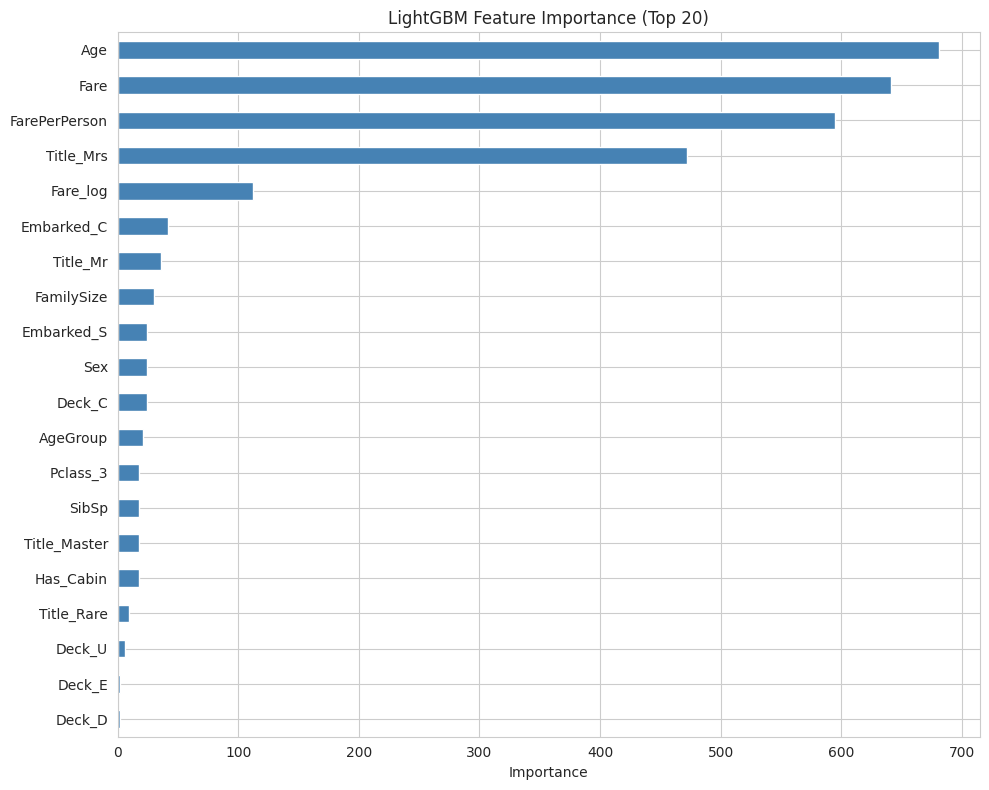

In [111]:
# Use the trained model to check feature importance
importances = lgbm_model.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_imp.tail(20).plot(kind='barh', color='steelblue')
plt.title('LightGBM Feature Importance (Top 20)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()